# Multi-Objective Network Optimization
## PROG2301 — LT6 Final Project
**Tasks Covered:** Task 1 (Network Design) · Task 2 (Adjacency Matrices & Tensor)

**Members:** Hannah Trajano · Uriel Orpilla · Adrien Maniquis · Elijah Haduca · Ethan Soriano · Hillary So · Chloe Ganaden

---
## Task 1 — Graph and Network Design
*(Hillary)*

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

### 2. Node Definitions

In [36]:
NODE_DESCRIPTIONS = {
    'A': 'Origin Node',
    'B': 'Regional Hub North',
    'C': 'Regional Hub South',
    'D': 'Distribution Point 1',
    'E': 'Distribution Point 2',
    'F': 'Distribution Point 3',
    'G': 'Local Node Alpha',
    'H': 'Local Node Beta',
    'I': 'Fulfillment Node',
    'J': 'Destination Node',
}

node_df = pd.DataFrame(
    [(node, desc) for node, desc in NODE_DESCRIPTIONS.items()],
    columns=['Node', 'Description']
)
print(node_df.to_string(index=False))

Node          Description
   A          Origin Node
   B   Regional Hub North
   C   Regional Hub South
   D Distribution Point 1
   E Distribution Point 2
   F Distribution Point 3
   G     Local Node Alpha
   H      Local Node Beta
   I     Fulfillment Node
   J     Destination Node


### 3. Edge Definitions

In [37]:
# Source Node, Destination Node, Time Value (Hours), Cost Value (USD), Connection Type
EDGE_LIST = [
    ('A', 'B', 4.0, 150, 'Primary Route'),
    ('A', 'C', 5.0, 180, 'Primary Route'),
    ('B', 'D', 2.0,  70, 'Regional Route'),
    ('B', 'E', 3.0,  90, 'Regional Route'),
    ('C', 'E', 2.5,  80, 'Regional Route'),
    ('C', 'F', 4.0, 110, 'Regional Route'),
    ('D', 'E', 1.0,  25, 'Inter-node Link'),
    ('D', 'G', 1.5,  40, 'Local Route'),
    ('E', 'H', 1.0,  30, 'Local Route'),
    ('E', 'I', 2.0,  60, 'Alternate Route'),
    ('F', 'H', 1.0,  75, 'Alternate Route'),
    ('F', 'I', 2.0,  55, 'Local Route'),
    ('H', 'I', 1.5,  30, 'Inter-node Link'),
    ('G', 'J', 1.2,  35, 'Final Route'),
    ('H', 'J', 1.8,  45, 'Final Route'),
    ('I', 'J', 1.5,  40, 'Final Route'),
]

edge_df = pd.DataFrame(
    EDGE_LIST,
    columns=['Source Node', 'Destination Node', 'Time Value (Hours)', 'Cost Value (USD)', 'Connection Type']
)
print(edge_df.to_string(index=False))

Source Node Destination Node  Time Value (Hours)  Cost Value (USD) Connection Type
          A                B                 4.0               150   Primary Route
          A                C                 5.0               180   Primary Route
          B                D                 2.0                70  Regional Route
          B                E                 3.0                90  Regional Route
          C                E                 2.5                80  Regional Route
          C                F                 4.0               110  Regional Route
          D                E                 1.0                25 Inter-node Link
          D                G                 1.5                40     Local Route
          E                H                 1.0                30     Local Route
          E                I                 2.0                60 Alternate Route
          F                H                 1.0                75 Alternate Route
    

### Network Visualization

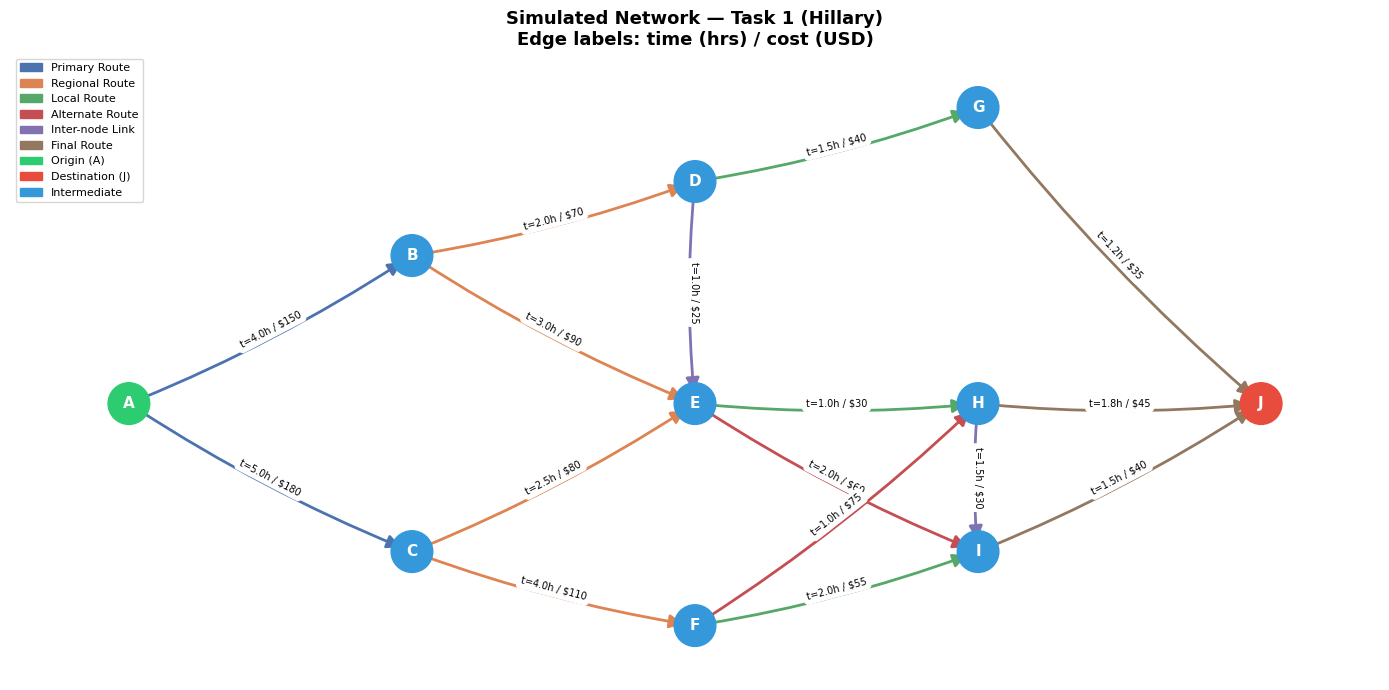

In [38]:
G_viz = nx.DiGraph()
for src, dst, t, c, conn in EDGE_LIST:
    G_viz.add_edge(src, dst, time=t, cost=c, ctype=conn)

POS = {
    'A':(0,2),'B':(1,3),'C':(1,1),'D':(2,3.5),
    'E':(2,2),'F':(2,0.5),'G':(3,4),'H':(3,2),'I':(3,1),'J':(4,2),
}
COLOR_MAP = {
    'Primary Route':   '#4C72B0',
    'Regional Route':  '#DD8452',
    'Local Route':     '#55A868',
    'Alternate Route': '#C44E52',
    'Inter-node Link': '#8172B2',
    'Final Route':     '#937860',
}
edge_colors = [COLOR_MAP[G_viz[u][v]['ctype']] for u, v in G_viz.edges()]
edge_labels = {(s,d): f't={t}h / ${c}' for s,d,t,c,_ in EDGE_LIST}
nc = ['#2ecc71' if n=='A' else '#e74c3c' if n=='J' else '#3498db' for n in G_viz.nodes()]

fig, ax = plt.subplots(figsize=(14, 7))
nx.draw_networkx_nodes(G_viz, POS, node_color=nc, node_size=900, ax=ax)
nx.draw_networkx_labels(G_viz, POS, font_color='white', font_weight='bold', font_size=11, ax=ax)
nx.draw_networkx_edges(G_viz, POS, edge_color=edge_colors, arrows=True,
                        arrowsize=20, width=2, connectionstyle='arc3,rad=0.05', ax=ax)
nx.draw_networkx_edge_labels(G_viz, POS, edge_labels=edge_labels, font_size=7, ax=ax)
patches = [mpatches.Patch(color=c, label=t) for t,c in COLOR_MAP.items()]
patches += [
    mpatches.Patch(color='#2ecc71', label='Origin (A)'),
    mpatches.Patch(color='#e74c3c', label='Destination (J)'),
    mpatches.Patch(color='#3498db', label='Intermediate'),
]
ax.legend(handles=patches, loc='upper left', fontsize=8)
ax.set_title('Simulated Network — Task 1 (Hillary)\nEdge labels: time (hrs) / cost (USD)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Task 2 — Data Structure Implementation: Adjacency Matrices & Tensor
*(Chloe & Ethan)*

Source: `tensor_builder.py`

In [39]:
# tensor_builder.py
# Task 2: Data Structure Implementation - Adjacency Matrices & Tensor
#
# This module builds:
# 1. a time adjacency matrix
# 2. a cost adjacency matrix
# 3. a stacked tensor containing both matrices
#
# The graph is directed, so an edge from A to B does not automatically mean
# there is also an edge from B to A.

import numpy as np

# Infinity means there is no direct edge between two nodes.
INF = float("inf")

# Fixed node order.
# This order determines the row and column positions in the matrices.
NODES = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]

In [40]:
# Edge list based on the finalized graph/network design.
# Format: (source_node, destination_node, time_value, cost_value)
EDGES = [
    ("A", "B", 4.0, 150),
    ("A", "C", 5.0, 180),
    ("B", "D", 2.0, 70),
    ("B", "E", 3.0, 90),
    ("C", "E", 2.5, 80),
    ("C", "F", 4.0, 110),
    ("D", "E", 1.0, 25),
    ("D", "G", 1.5, 40),
    ("E", "H", 1.0, 30),
    ("E", "I", 2.0, 60),
    ("F", "H", 1.0, 75),
    ("F", "I", 2.0, 55),
    ("H", "I", 1.5, 30),
    ("G", "J", 1.2, 35),
    ("H", "J", 1.8, 45),
    ("I", "J", 1.5, 40),
]

In [41]:
def build_node_index(nodes: list) -> dict:
    """
    Creates a dictionary that maps each node label to its matrix index.
    Example:
    A -> 0
    B -> 1
    C -> 2
    """
    return {node: index for index, node in enumerate(nodes)}

In [42]:
def validate_edges(
    nodes: list,
    edges: list,
) -> None:
    """
    Checks if all edges are valid before building the matrices.
    """
    node_set = set(nodes)
    for source, destination, time_value, cost_value in edges:
        if source not in node_set:
            raise ValueError(f"Invalid source node: {source}")
        if destination not in node_set:
            raise ValueError(f"Invalid destination node: {destination}")
        if time_value < 0:
            raise ValueError(
                f"Time cannot be negative for edge {source} -> {destination}"
            )
        if cost_value < 0:
            raise ValueError(
                f"Cost cannot be negative for edge {source} -> {destination}"
            )

In [43]:
def build_adjacency_matrices(
    nodes: list = NODES,
    edges: list = EDGES,
) -> tuple:
    """
    Builds the time and cost adjacency matrices.
    Returns:
        time_matrix: adjacency matrix using time as edge weight
        cost_matrix: adjacency matrix using cost as edge weight
        node_index: dictionary mapping node labels to matrix indices
    """
    validate_edges(nodes, edges)
    size = len(nodes)
    node_index = build_node_index(nodes)

    # Start with infinity to show that most node pairs have no direct edge.
    time_matrix = np.full((size, size), INF)
    cost_matrix = np.full((size, size), INF)

    # Cost from a node to itself is zero.
    np.fill_diagonal(time_matrix, 0)
    np.fill_diagonal(cost_matrix, 0)

    # Fill in the directed edges.
    for source, destination, time_value, cost_value in edges:
        row = node_index[source]
        col = node_index[destination]
        time_matrix[row][col] = time_value
        cost_matrix[row][col] = cost_value

    return time_matrix, cost_matrix, node_index

In [44]:
def build_tensor(
    time_matrix: np.ndarray,
    cost_matrix: np.ndarray,
) -> np.ndarray:
    """
    Stacks the time and cost matrices into one tensor.
    Tensor shape:
        (2, number_of_nodes, number_of_nodes)
    tensor[0] = time matrix
    tensor[1] = cost matrix
    """
    return np.stack([time_matrix, cost_matrix])

In [45]:
def get_neighbors(
    matrix: np.ndarray,
    node: str,
    node_index: dict,
    nodes: list = NODES,
) -> list:
    """
    Returns the outgoing neighbors of a given node based on a selected matrix.
    This helper function can be used by the Dijkstra and Pareto teams.
    """
    row = node_index[node]
    neighbors = []
    for col, weight in enumerate(matrix[row]):
        if weight != INF and weight != 0:
            neighbors.append((nodes[col], weight))
    return neighbors

In [46]:
def print_matrix(matrix: np.ndarray, title: str) -> None:
    """
    Prints a readable version of a matrix.
    """
    print(f"\n{title}")
    print("-" * len(title))
    for row in matrix:
        print(row)

### Run — equivalent of `if __name__ == '__main__'`

In [47]:
time_matrix, cost_matrix, node_index = build_adjacency_matrices()
tensor = build_tensor(time_matrix, cost_matrix)

print("Node Index:")
print(node_index)

print_matrix(time_matrix, "Time Matrix")
print_matrix(cost_matrix, "Cost Matrix")

print("\nTensor Shape:")
print(tensor.shape)

print("\nTensor Meaning:")
print("tensor[0] = time matrix")
print("tensor[1] = cost matrix")

print("\nNeighbors of A using time matrix:")
print(get_neighbors(time_matrix, "A", node_index))

Node Index:
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9}

Time Matrix
-----------
[ 0.  4.  5. inf inf inf inf inf inf inf]
[inf  0. inf  2.  3. inf inf inf inf inf]
[inf inf 0.  inf 2.5 4.  inf inf inf inf]
[inf inf inf 0.  1.  inf 1.5 inf inf inf]
[inf inf inf inf  0. inf inf  1.  2. inf]
[inf inf inf inf inf  0. inf  1.  2. inf]
[inf inf inf inf inf inf 0.  inf inf 1.2]
[inf inf inf inf inf inf inf 0.  1.5 1.8]
[inf inf inf inf inf inf inf inf 0.  1.5]
[inf inf inf inf inf inf inf inf inf  0.]

Cost Matrix
-----------
[  0. 150. 180.  inf  inf  inf  inf  inf  inf  inf]
[inf  0. inf 70. 90. inf inf inf inf inf]
[ inf  inf   0.  inf  80. 110.  inf  inf  inf  inf]
[inf inf inf  0. 25. inf 40. inf inf inf]
[inf inf inf inf  0. inf inf 30. 60. inf]
[inf inf inf inf inf  0. inf 75. 55. inf]
[inf inf inf inf inf inf  0. inf inf 35.]
[inf inf inf inf inf inf inf  0. 30. 45.]
[inf inf inf inf inf inf inf inf  0. 40.]
[inf inf inf inf inf inf inf inf inf  0

In [48]:
import heapq

def dijkstra(matrix, source, target, node_index, nodes=NODES):
    """
    Dijkstra-style single-objective shortest path.
    
    Args:
        matrix     : either time_matrix or cost_matrix (NxN ndarray)
        source     : start node label e.g. "A"
        target     : end node label e.g. "J"
        node_index : dict from build_node_index()
        nodes      : ordered list of node labels
    
    Returns:
        path       : list of node labels e.g. ["A", "B", "D", "G", "J"]
        total_cost : float, total weight along that path
    """
    n = len(nodes)

    # 1. Cost tracker — best known cost to reach each node
    dist = {node: float("inf") for node in nodes}
    dist[source] = 0.0

    # 2. Parent tracker — for reconstructing the path at the end
    parent = {node: None for node in nodes}

    # 3. Visited set — once a node is popped, its cost is finalized
    visited = set()

    # 4. Priority queue — (cost_so_far, node_label)
    pq = [(0.0, source)]

    while pq:
        current_cost, current_node = heapq.heappop(pq)

        if current_node in visited:
            continue
        visited.add(current_node)

        # Early exit once target is settled
        if current_node == target:
            break

        # Relax neighbors
        for neighbor, weight in get_neighbors(matrix, current_node, node_index, nodes):
            if neighbor in visited:
                continue
            new_cost = current_cost + weight
            if new_cost < dist[neighbor]:
                dist[neighbor] = new_cost
                parent[neighbor] = current_node
                heapq.heappush(pq, (new_cost, neighbor))

    # Reconstruct path by walking parent pointers back from target
    if dist[target] == float("inf"):
        return None, float("inf")  # no path exists

    path = []
    node = target
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()

    return path, dist[target]

In [49]:
# minimize time
path, total_time = dijkstra(time_matrix, "A", "J", node_index)
print(f"Fastest path: {' -> '.join(path)}, time: {total_time}h")

# minimize cost
path, total_cost = dijkstra(cost_matrix, "A", "J", node_index)
print(f"Cheapest path: {' -> '.join(path)}, cost: ${total_cost}")

Fastest path: A -> B -> D -> G -> J, time: 8.7h
Cheapest path: A -> B -> D -> G -> J, cost: $295.0


In [50]:
from scipy.sparse.csgraph import dijkstra as scipy_dijkstra
from scipy.sparse import csr_matrix
import numpy as np

def scipy_shortest_path(matrix, source, target, node_index, nodes=NODES):
    """
    Scipy version — used to verify the manual Dijkstra output.
    """
    # scipy can't handle float("inf") directly, replace with 0 for sparse
    # (sparse format treats 0 as no edge, which is what we want)
    sparse_matrix = np.where(np.isinf(matrix), 0, matrix)
    # but diagonal is also 0 — fill diagonal with inf first so scipy ignores self
    np.fill_diagonal(sparse_matrix, 0)  # sparse ignores zeros = no self-loop issue

    graph = csr_matrix(sparse_matrix)
    src_idx = node_index[source]
    tgt_idx = node_index[target]

    dist_matrix, predecessors = scipy_dijkstra(
        graph, directed=True, indices=src_idx, return_predecessors=True
    )

    total_cost = dist_matrix[tgt_idx]

    # Reconstruct path from predecessor array
    path = []
    node = tgt_idx
    while node != src_idx:
        path.append(nodes[node])
        node = predecessors[node]
        if node == -9999:  # scipy's sentinel for "no predecessor"
            return None, float("inf")
    path.append(nodes[src_idx])
    path.reverse()

    return path, total_cost

In [51]:
def generate_all_routes(
    time_matrix: np.ndarray,
    cost_matrix: np.ndarray,
    source: str,
    destination: str,
    node_index: dict[str, int],
    nodes: list[str] = NODES,
) -> list[dict]:
    """
    Generates all simple paths from source to destination using DFS.
    Each route is stored as a dict with its path, total time, and total cost.
    """
    index_to_node = {v: k for k, v in node_index.items()}
    src_idx = node_index[source]
    dst_idx = node_index[destination]
    n = len(nodes)

    all_routes = []

    # Stack entries: (current_node_idx, visited_set, cumulative_time, cumulative_cost, path)
    stack = [(src_idx, {src_idx}, 0.0, 0.0, [source])]

    while stack:
        curr, visited, cum_time, cum_cost, path = stack.pop()

        if curr == dst_idx:
            all_routes.append({
                "path": path,
                "time": cum_time,
                "cost": cum_cost,
            })
            continue

        for neighbor_idx in range(n):
            t = time_matrix[curr][neighbor_idx]
            c = cost_matrix[curr][neighbor_idx]

            if t == INF or t == 0:
                continue
            if neighbor_idx in visited:
                continue

            stack.append((
                neighbor_idx,
                visited | {neighbor_idx},
                cum_time + t,
                cum_cost + c,
                path + [index_to_node[neighbor_idx]],
            ))

    return all_routes

# Quick check
sample_routes = generate_all_routes(time_matrix, cost_matrix, "A", "J", node_index)
print(f"Total candidate routes from A to J: {len(sample_routes)}")
for r in sample_routes:
    print(f"  {' -> '.join(r['path'])} | time={r['time']:.1f}h | cost=${r['cost']:.0f}")

Total candidate routes from A to J: 13
  A -> C -> F -> I -> J | time=12.5h | cost=$385
  A -> C -> F -> H -> J | time=11.8h | cost=$410
  A -> C -> F -> H -> I -> J | time=13.0h | cost=$435
  A -> C -> E -> I -> J | time=11.0h | cost=$360
  A -> C -> E -> H -> J | time=10.3h | cost=$335
  A -> C -> E -> H -> I -> J | time=11.5h | cost=$360
  A -> B -> E -> I -> J | time=10.5h | cost=$340
  A -> B -> E -> H -> J | time=9.8h | cost=$315
  A -> B -> E -> H -> I -> J | time=11.0h | cost=$340
  A -> B -> D -> G -> J | time=8.7h | cost=$295
  A -> B -> D -> E -> I -> J | time=10.5h | cost=$345
  A -> B -> D -> E -> H -> J | time=9.8h | cost=$320
  A -> B -> D -> E -> H -> I -> J | time=11.0h | cost=$345


PARETO

## Requirements Coverage Map

### "Starting from the source node, generate candidate routes through graph traversal"
→ **Cell 3** — `generate_candidate_routes()` does iterative DFS from source, exploring every simple path to destination

---

### "Represent each as a [time, cost] vector"
→ **Cell 2** — the `Route` class stores `self.objectives = np.array([total_time, total_cost])` for every path found

---

### "Apply Pareto dominance filtering (a route is dominated if another route is no worse in both objectives and strictly better in at least one)"
→ **Cell 4** — `dominates()` implements exactly that definition using numpy vector comparison  
→ **Cell 5** — `pareto_filter()` applies it across all candidates, eliminating anything that gets dominated

---

### "The non-dominated routes that survive filtering are the final algorithm output presented to the user"
→ **Cell 6** — `pareto_search()` is the main function that runs the full pipeline and returns `pareto_front` as the primary output, not candidates  
→ **Cell 7** — `display_pareto_results()` presents the surviving routes to the user with trade-off analysis

---

### "The algorithm itself both generates AND filters candidate routes"
→ Both happen inside `pareto_search()` — it calls `generate_candidate_routes()` then `pareto_filter()` internally. The user just calls one function and gets the Pareto-optimal set back.

---

### "Returning the Pareto-optimal set as the actual solution (not a validation step)"
→ The brute-force in **Cell 11** is explicitly labeled as a *verifier* and is separate from the main pipeline. `pareto_search()` itself is the solution — Cell 11 just checks that it's correct.

In [52]:
from __future__ import annotations
import numpy as np
import heapq
from itertools import combinations

try:
    NODES
    time_matrix
    cost_matrix
    node_index
    print("Using existing NODES, matrices, and node_index from tensor_builder.")
except NameError:
    INF = float("inf")
    NODES = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]
    EDGES = [
        ("A", "B", 4.0, 150), ("A", "C", 5.0, 180),
        ("B", "D", 2.0, 70),  ("B", "E", 3.0, 90),
        ("C", "E", 2.5, 80),  ("C", "F", 4.0, 110),
        ("D", "E", 1.0, 25),  ("D", "G", 1.5, 40),
        ("E", "H", 1.0, 30),  ("E", "I", 2.0, 60),
        ("F", "H", 1.0, 75),  ("F", "I", 2.0, 55),
        ("H", "I", 1.5, 30),  ("G", "J", 1.2, 35),
        ("H", "J", 1.8, 45),  ("I", "J", 1.5, 40),
    ]
    node_index = {node: i for i, node in enumerate(NODES)}
    size = len(NODES)
    time_matrix = np.full((size, size), INF)
    cost_matrix = np.full((size, size), INF)
    np.fill_diagonal(time_matrix, 0)
    np.fill_diagonal(cost_matrix, 0)
    for src, dst, t, c in EDGES:
        r, col = node_index[src], node_index[dst]
        time_matrix[r][col] = t
        cost_matrix[r][col] = c
    print("Built NODES, matrices, and node_index from scratch.")

Using existing NODES, matrices, and node_index from tensor_builder.


In [53]:
class Route:
    """
    Represents a single candidate route as a [time, cost] vector.
    
    This is the core data structure for multi-objective Pareto search.
    Each route stores:
      - path       : ordered list of node labels from source to destination
      - objectives : numpy array [total_time, total_cost] — the cost vector
    """

    def __init__(self, path: list[str], total_time: float, total_cost: float):
        self.path = path
        self.objectives = np.array([total_time, total_cost], dtype=float)

    @property
    def time(self) -> float:
        return self.objectives[0]

    @property
    def cost(self) -> float:
        return self.objectives[1]

    @property
    def path_str(self) -> str:
        return " -> ".join(self.path)

    def __repr__(self) -> str:
        return (
            f"Route({self.path_str} | "
            f"time={self.time:.2f}h, cost=${self.cost:.2f})"
        )

    def to_dict(self) -> dict:
        return {
            "path": self.path,
            "time": self.time,
            "cost": self.cost,
            "objectives": self.objectives.tolist(),
        }


demo_route = Route(["A", "B", "D", "G", "J"], 4.0 + 2.0 + 1.5 + 1.2, 150 + 70 + 40 + 35)
print("Demo Route:")
print(f"  Path       : {demo_route.path_str}")
print(f"  Objectives : {demo_route.objectives}")
print(f"  Time       : {demo_route.time:.2f}h")
print(f"  Cost       : ${demo_route.cost:.2f}")

Demo Route:
  Path       : A -> B -> D -> G -> J
  Objectives : [  8.7 295. ]
  Time       : 8.70h
  Cost       : $295.00


In [54]:
def generate_candidate_routes(
    time_matrix: np.ndarray,
    cost_matrix: np.ndarray,
    source: str,
    destination: str,
    node_index: dict[str, int],
    nodes: list[str] = NODES,
) -> list[Route]:
    """
    Generates all simple paths from source to destination via iterative DFS.
    
    Each discovered path is converted into a Route object with a [time, cost]
    objective vector. Self-loops and revisited nodes are excluded.

    Returns:
        List of Route objects — one per simple path found.
    """
    if source not in node_index:
        raise ValueError(f"Source node '{source}' not found.")
    if destination not in node_index:
        raise ValueError(f"Destination node '{destination}' not found.")
    if source == destination:
        raise ValueError("Source and destination must be different nodes.")

    index_to_node = {v: k for k, v in node_index.items()}
    src_idx = node_index[source]
    dst_idx = node_index[destination]
    n = len(nodes)
    routes = []

    stack = [(src_idx, frozenset([src_idx]), 0.0, 0.0, [source])]

    while stack:
        curr_idx, visited, cum_time, cum_cost, path = stack.pop()

        if curr_idx == dst_idx:
            routes.append(Route(path[:], cum_time, cum_cost))
            continue

        for neighbor_idx in range(n):
            t = time_matrix[curr_idx][neighbor_idx]
            c = cost_matrix[curr_idx][neighbor_idx]

            # if no edge, self-loop, or already visited
            if t == INF or t == 0:
                continue
            if neighbor_idx in visited:
                continue

            stack.append((
                neighbor_idx,
                visited | frozenset([neighbor_idx]),
                cum_time + t,
                cum_cost + c,
                path + [index_to_node[neighbor_idx]],
            ))

    return routes


# display all routes from a to j
candidates = generate_candidate_routes(time_matrix, cost_matrix, "A", "J", node_index)

print(f"Total candidate routes found (A -> J): {len(candidates)}\n")
print(f"  {'#':<4} {'Path':<35} {'Time (h)':>9} {'Cost ($)':>10}")
print(f"  {'-'*4} {'-'*35} {'-'*9} {'-'*10}")
for i, r in enumerate(candidates, 1):
    print(f"  {i:<4} {r.path_str:<35} {r.time:>9.2f} {r.cost:>10.2f}")

Total candidate routes found (A -> J): 13

  #    Path                                 Time (h)   Cost ($)
  ---- ----------------------------------- --------- ----------
  1    A -> C -> F -> I -> J                   12.50     385.00
  2    A -> C -> F -> H -> J                   11.80     410.00
  3    A -> C -> F -> H -> I -> J              13.00     435.00
  4    A -> C -> E -> I -> J                   11.00     360.00
  5    A -> C -> E -> H -> J                   10.30     335.00
  6    A -> C -> E -> H -> I -> J              11.50     360.00
  7    A -> B -> E -> I -> J                   10.50     340.00
  8    A -> B -> E -> H -> J                    9.80     315.00
  9    A -> B -> E -> H -> I -> J              11.00     340.00
  10   A -> B -> D -> G -> J                    8.70     295.00
  11   A -> B -> D -> E -> I -> J              10.50     345.00
  12   A -> B -> D -> E -> H -> J               9.80     320.00
  13   A -> B -> D -> E -> H -> I -> J         11.00     345.

In [55]:
def dominates(route_a: Route, route_b: Route) -> bool:
    """
    Returns True if route_a dominates route_b under Pareto dominance.

    Definition:
        route_a dominates route_b if and only if:
          (1) route_a is no worse than route_b in ALL objectives
          (2) route_a is strictly better than route_b in AT LEAST ONE objective

    For this problem, lower is better for both time and cost.

    This uses numpy vector comparison for clean generalization
    across any number of objectives.
    """
    no_worse_in_all    = np.all(route_a.objectives <= route_b.objectives)
    better_in_at_least_one = np.any(route_a.objectives <  route_b.objectives)
    return bool(no_worse_in_all and better_in_at_least_one)


def dominance_relation(route_a: Route, route_b: Route) -> str:
    """
    Returns a human-readable dominance relationship between two routes.
    Useful for debugging and explanation.
    """
    if dominates(route_a, route_b):
        return "A dominates B"
    elif dominates(route_b, route_a):
        return "B dominates A"
    elif np.array_equal(route_a.objectives, route_b.objectives):
        return "A and B are identical in objectives"
    else:
        return "A and B are non-dominated (incomparable)"


# demo
print("dominance relaitonship demo")

test_pairs = [
    (Route(["A","B","J"], 5.0, 100), Route(["A","C","J"], 6.0, 120), "faster AND cheaper"),
    (Route(["A","B","J"], 5.0, 100), Route(["A","C","J"], 4.0, 120), "faster but more expensive"),
    (Route(["A","B","J"], 5.0, 100), Route(["A","C","J"], 5.0, 100), "identical objectives"),
    (Route(["A","B","J"], 5.0, 130), Route(["A","C","J"], 6.0, 100), "trade-off: neither dominates"),
]

for a, b, desc in test_pairs:
    rel = dominance_relation(a, b)
    print(f"  Scenario : {desc}")
    print(f"  Route A  : time={a.time:.1f}h  cost=${a.cost:.0f}")
    print(f"  Route B  : time={b.time:.1f}h  cost=${b.cost:.0f}")
    print(f"  Result   : {rel}\n")

dominance relaitonship demo
  Scenario : faster AND cheaper
  Route A  : time=5.0h  cost=$100
  Route B  : time=6.0h  cost=$120
  Result   : A dominates B

  Scenario : faster but more expensive
  Route A  : time=5.0h  cost=$100
  Route B  : time=4.0h  cost=$120
  Result   : A and B are non-dominated (incomparable)

  Scenario : identical objectives
  Route A  : time=5.0h  cost=$100
  Route B  : time=5.0h  cost=$100
  Result   : A and B are identical in objectives

  Scenario : trade-off: neither dominates
  Route A  : time=5.0h  cost=$130
  Route B  : time=6.0h  cost=$100
  Result   : A and B are non-dominated (incomparable)



In [56]:
def pareto_filter(routes: list[Route]) -> list[Route]:
    """
    Filters a list of Route objects and returns only the Pareto-optimal front.

    Algorithm:
      For each candidate route, check if any OTHER route dominates it.
      If no other route dominates it, it survives into the Pareto front.

    Time complexity: O(n^2 * m) where n = number of routes, m = number of objectives.
    For small graphs with few objectives this is entirely acceptable.

    Returns:
        Sorted list of non-dominated Route objects (sorted by time ascending).
    """
    if not routes:
        return []

    pareto_front = []

    for i, candidate in enumerate(routes):
        is_dominated = False
        for j, other in enumerate(routes):
            if i == j:
                continue
            if dominates(other, candidate):
                is_dominated = True
                break
        if not is_dominated:
            pareto_front.append(candidate)

    # sort by ascending time, then by ascending cost
    pareto_front.sort(key=lambda r: (r.time, r.cost))
    return pareto_front


def identify_dominated_routes(routes: list[Route]) -> list[tuple[Route, Route]]:
    """
    Returns a list of (dominated_route, dominating_route) pairs.
    Useful for explaining WHY certain routes were eliminated.
    """
    dominated_pairs = []
    for i, candidate in enumerate(routes):
        for j, other in enumerate(routes):
            if i == j:
                continue
            if dominates(other, candidate):
                dominated_pairs.append((candidate, other))
                break
    return dominated_pairs


# filtering from a to j
pareto_front = pareto_filter(candidates)
dominated_pairs = identify_dominated_routes(candidates)
dominated_routes = {id(pair[0]) for pair in dominated_pairs}

print(f"Pareto Filtering Results (A -> J)")
print("=" * 55)
print(f"  Candidates total  : {len(candidates)}")
print(f"  Dominated removed : {len(dominated_pairs)}")
print(f"  Pareto front size : {len(pareto_front)}\n")

print("Eliminated Routes (with reason):")
print(f"  {'-'*52}")
for dominated, dominator in dominated_pairs:
    print(f"  DOMINATED : {dominated.path_str}")
    print(f"             [time={dominated.time:.2f}h, cost=${dominated.cost:.2f}]")
    print(f"  BY        : {dominator.path_str}")
    print(f"             [time={dominator.time:.2f}h, cost=${dominator.cost:.2f}]")
    print()

Pareto Filtering Results (A -> J)
  Candidates total  : 13
  Dominated removed : 12
  Pareto front size : 1

Eliminated Routes (with reason):
  ----------------------------------------------------
  DOMINATED : A -> C -> F -> I -> J
             [time=12.50h, cost=$385.00]
  BY        : A -> C -> E -> I -> J
             [time=11.00h, cost=$360.00]

  DOMINATED : A -> C -> F -> H -> J
             [time=11.80h, cost=$410.00]
  BY        : A -> C -> E -> I -> J
             [time=11.00h, cost=$360.00]

  DOMINATED : A -> C -> F -> H -> I -> J
             [time=13.00h, cost=$435.00]
  BY        : A -> C -> F -> I -> J
             [time=12.50h, cost=$385.00]

  DOMINATED : A -> C -> E -> I -> J
             [time=11.00h, cost=$360.00]
  BY        : A -> C -> E -> H -> J
             [time=10.30h, cost=$335.00]

  DOMINATED : A -> C -> E -> H -> J
             [time=10.30h, cost=$335.00]
  BY        : A -> B -> E -> H -> J
             [time=9.80h, cost=$315.00]

  DOMINATED : A -> C -> 

In [57]:
def pareto_search(
    time_matrix: np.ndarray,
    cost_matrix: np.ndarray,
    source: str,
    destination: str,
    node_index: dict[str, int],
    nodes: list[str] = NODES,
) -> dict:
    """
    Full multi-objective Pareto-front search.

    Pipeline:
      Step 1 — Graph traversal (DFS) to generate all simple candidate routes
      Step 2 — Represent each route as a [time, cost] objective vector
      Step 3 — Apply Pareto dominance filtering
      Step 4 — Return the non-dominated set as the final algorithm output

    This is the PRIMARY multi-objective answer — not a validation step.

    Returns:
        dict with keys:
          source           : source node label
          destination      : destination node label
          candidates       : all Route objects generated
          pareto_front     : non-dominated Route objects (the answer)
          dominated_pairs  : list of (eliminated_route, eliminator) pairs
          dominated_count  : number of routes eliminated
          fastest_route    : Route with lowest time on the Pareto front
          cheapest_route   : Route with lowest cost on the Pareto front
    """
    candidates = generate_candidate_routes(
        time_matrix, cost_matrix, source, destination, node_index, nodes
    )

    if not candidates:
        return {
            "source": source,
            "destination": destination,
            "candidates": [],
            "pareto_front": [],
            "dominated_pairs": [],
            "dominated_count": 0,
            "fastest_route": None,
            "cheapest_route": None,
        }

    front = pareto_filter(candidates)
    dominated_pairs = identify_dominated_routes(candidates)

    fastest  = min(front, key=lambda r: r.time)
    cheapest = min(front, key=lambda r: r.cost)

    return {
        "source": source,
        "destination": destination,
        "candidates": candidates,
        "pareto_front": front,
        "dominated_pairs": dominated_pairs,
        "dominated_count": len(dominated_pairs),
        "fastest_route": fastest,
        "cheapest_route": cheapest,
    }

In [58]:
def display_pareto_results(result: dict, show_dominated: bool = True) -> None:
    """
    Prints a full formatted report of the Pareto search result.

    Parameters:
        result          : output dict from pareto_search()
        show_dominated  : if True, also prints eliminated routes with reasons
    """
    src   = result["source"]
    dst   = result["destination"]
    front = result["pareto_front"]
    total = len(result["candidates"])

    print(f"\n{'='*60}")
    print(f"  PARETO-FRONT SEARCH  |  {src}  →  {dst}")
    print(f"{'='*60}")
    print(f"  Candidates generated : {total}")
    print(f"  Dominated removed    : {result['dominated_count']}")
    print(f"  Pareto-optimal found : {len(front)}")
    print(f"{'-'*60}")

    if not front:
        print("  No routes found between these nodes.")
        print(f"{'='*60}")
        return

    # pareto front table
    print(f"\n  PARETO-OPTIMAL ROUTES (the multi-objective answer):\n")
    print(f"  {'#':<4} {'Path':<35} {'Time (h)':>9} {'Cost ($)':>10}  Note")
    print(f"  {'-'*4} {'-'*35} {'-'*9} {'-'*10}  {'-'*15}")

    fastest_id  = id(result["fastest_route"])
    cheapest_id = id(result["cheapest_route"])

    for i, r in enumerate(front, 1):
        note = ""
        if id(r) == fastest_id and id(r) == cheapest_id:
            note = "◀ fastest & cheapest"
        elif id(r) == fastest_id:
            note = "◀ fastest"
        elif id(r) == cheapest_id:
            note = "◀ cheapest"
        print(f"  {i:<4} {r.path_str:<35} {r.time:>9.2f} {r.cost:>10.2f}  {note}")

    # vector summary
    print(f"\n  Objective vectors [time, cost]:")
    for r in front:
        print(f"    {r.path_str:<35} → {r.objectives}")

    # tradeoffs
    if len(front) > 1:
        print(f"\n  Trade-off analysis:")
        fastest  = result["fastest_route"]
        cheapest = result["cheapest_route"]
        time_diff = cheapest.time - fastest.time
        cost_diff = fastest.cost - cheapest.cost
        print(f"    Taking the fastest route costs ${cost_diff:.2f} more than the cheapest.")
        print(f"    Taking the cheapest route takes {time_diff:.2f}h longer than the fastest.")

    # eliminated routes
    if show_dominated and result["dominated_pairs"]:
        print(f"\n  ELIMINATED ROUTES (dominated):\n")
        for dominated, dominator in result["dominated_pairs"]:
            print(f"    X {dominated.path_str}")
            print(f"        [time={dominated.time:.2f}h, cost=${dominated.cost:.2f}]")
            print(f"      dominated by → {dominator.path_str}")
            print(f"        [time={dominator.time:.2f}h, cost=${dominator.cost:.2f}]")
            print()


In [59]:
result_AJ = pareto_search(time_matrix, cost_matrix, "A", "J", node_index)
display_pareto_results(result_AJ, show_dominated=True)


  PARETO-FRONT SEARCH  |  A  →  J
  Candidates generated : 13
  Dominated removed    : 12
  Pareto-optimal found : 1
------------------------------------------------------------

  PARETO-OPTIMAL ROUTES (the multi-objective answer):

  #    Path                                 Time (h)   Cost ($)  Note
  ---- ----------------------------------- --------- ----------  ---------------
  1    A -> B -> D -> G -> J                    8.70     295.00  ◀ fastest & cheapest

  Objective vectors [time, cost]:
    A -> B -> D -> G -> J               → [  8.7 295. ]

  ELIMINATED ROUTES (dominated):

    X A -> C -> F -> I -> J
        [time=12.50h, cost=$385.00]
      dominated by → A -> C -> E -> I -> J
        [time=11.00h, cost=$360.00]

    X A -> C -> F -> H -> J
        [time=11.80h, cost=$410.00]
      dominated by → A -> C -> E -> I -> J
        [time=11.00h, cost=$360.00]

    X A -> C -> F -> H -> I -> J
        [time=13.00h, cost=$435.00]
      dominated by → A -> C -> F -> I -> J
  

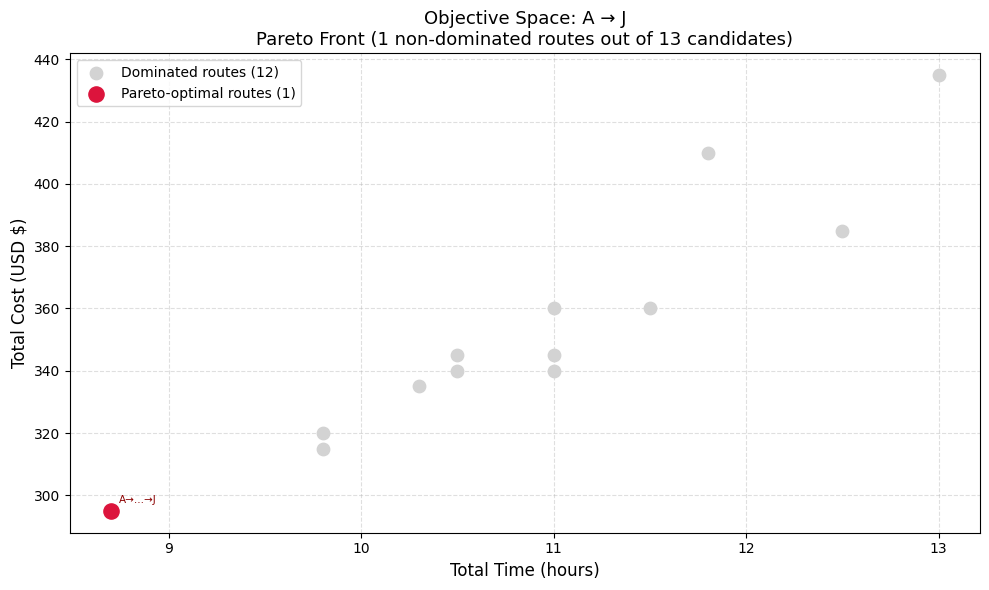

In [60]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_objective_space(result: dict) -> None:
    """
    Plots all candidate routes in [time, cost] objective space.
    
    - Grey points  : dominated routes (eliminated)
    - Red points   : Pareto-optimal routes (the answer)
    - Red line     : the Pareto front boundary
    - Annotations  : abbreviated path labels on Pareto-optimal points
    """
    candidates = result["candidates"]
    front      = result["pareto_front"]
    src        = result["source"]
    dst        = result["destination"]

    dominated_routes = {
        id(pair[0]) for pair in result["dominated_pairs"]
    }

    dom_times  = [r.time for r in candidates if id(r) in dominated_routes]
    dom_costs  = [r.cost for r in candidates if id(r) in dominated_routes]
    front_times = [r.time for r in front]
    front_costs = [r.cost for r in front]

    fig, ax = plt.subplots(figsize=(10, 6))

    # Dominated routes
    ax.scatter(dom_times, dom_costs, color="lightgrey", s=80,
               zorder=2, label=f"Dominated routes ({len(dom_times)})")

    # Pareto front points
    ax.scatter(front_times, front_costs, color="crimson", s=120,
               zorder=4, label=f"Pareto-optimal routes ({len(front)})")

    # Pareto front boundary line (step function — staircase shape)
    sorted_front = sorted(front, key=lambda r: r.time)
    step_times = [r.time for r in sorted_front]
    step_costs = [r.cost for r in sorted_front]
    ax.step(step_times, step_costs, where="post", color="crimson",
            linewidth=1.5, linestyle="--", zorder=3, alpha=0.7)

    # Annotate Pareto-optimal routes
    for r in front:
        label = r.path_str if len(r.path) <= 4 else (
            r.path[0] + "→...→" + r.path[-1]
        )
        ax.annotate(
            label,
            xy=(r.time, r.cost),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=7.5,
            color="darkred",
        )

    ax.set_xlabel("Total Time (hours)", fontsize=12)
    ax.set_ylabel("Total Cost (USD $)", fontsize=12)
    ax.set_title(
        f"Objective Space: {src} → {dst}\n"
        f"Pareto Front ({len(front)} non-dominated routes out of {len(candidates)} candidates)",
        fontsize=13,
    )
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


plot_objective_space(result_AJ)

# Testing

In [72]:
import random
NODES = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T", "U", "V"]

def randomize_test_graph(
    nodes=NODES,
    edges=EDGES,
    min_nodes=3,
    max_nodes=None,
    time_range=(1, 10),
    money_range=(30, 200),
):
    """
    Randomize the number of nodes and edge weights using the provided node/edge definitions.
    Ensures exactly one start node 'A' and one end node.
    Also ensures no node other than the end node becomes a dead end.
    """
    if max_nodes is None:
        max_nodes = len(nodes)
    if not (2 <= min_nodes <= max_nodes <= len(nodes)):
        raise ValueError("Invalid node range")

    node_count = random.randint(min_nodes, max_nodes)
    selected_nodes = list(nodes[:node_count])
    start_node = "A"
    end_node = selected_nodes[-1]

    randomized_edges = []
    outgoing_edges = {node: set() for node in selected_nodes}

    for src, dst, _, _ in edges:
        if src not in selected_nodes or dst not in selected_nodes:
            continue
        if src == end_node:
            continue
        if src == start_node and dst == end_node:
            continue

        randomized_edges.append(
            (
                src,
                dst,
                random.randint(*time_range),
                random.randint(*money_range),
            )
        )
        outgoing_edges[src].add(dst)

    if not any(src == start_node for src, *_ in randomized_edges):
        first_target = selected_nodes[1] if len(selected_nodes) > 1 else end_node
        randomized_edges.append(
            (start_node, first_target, random.randint(*time_range), random.randint(*money_range))
        )
        outgoing_edges[start_node].add(first_target)

    if not any(dst == end_node for _, dst, *_ in randomized_edges):
        last_source = selected_nodes[-2] if len(selected_nodes) > 1 else start_node
        randomized_edges.append(
            (last_source, end_node, random.randint(*time_range), random.randint(*money_range))
        )
        outgoing_edges[last_source].add(end_node)

    for node in selected_nodes[:-1]:
        if not outgoing_edges[node]:
            next_index = selected_nodes.index(node) + 1
            next_node = selected_nodes[next_index] if next_index < len(selected_nodes) else end_node
            randomized_edges.append(
                (node, next_node, random.randint(*time_range), random.randint(*money_range))
            )
            outgoing_edges[node].add(next_node)

    return {
        "nodes": selected_nodes,
        "edges": randomized_edges,
        "start": start_node,
        "end": end_node,
    }


random_test_case = randomize_test_graph(max_nodes=22)
random_test_case


{'nodes': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L'],
 'edges': [('A', 'B', 8, 77),
  ('A', 'C', 5, 136),
  ('B', 'D', 3, 53),
  ('B', 'E', 4, 178),
  ('C', 'E', 5, 134),
  ('C', 'F', 10, 104),
  ('D', 'E', 3, 168),
  ('D', 'G', 9, 83),
  ('E', 'H', 9, 39),
  ('E', 'I', 3, 155),
  ('F', 'H', 6, 123),
  ('F', 'I', 4, 164),
  ('H', 'I', 10, 84),
  ('G', 'J', 3, 65),
  ('H', 'J', 4, 200),
  ('I', 'J', 4, 73),
  ('K', 'L', 2, 58),
  ('J', 'K', 4, 93)],
 'start': 'A',
 'end': 'L'}

In [73]:
import numpy as np

# Use the same adjacency-matrix approach from Cells 5-13 on the randomized graph
random_nodes = random_test_case["nodes"]
random_edges = random_test_case["edges"]
random_start = random_test_case["start"]
random_end = random_test_case["end"]

node_index = {node: i for i, node in enumerate(random_nodes)}
size = len(random_nodes)

random_time_matrix = np.full((size, size), float("inf"))
random_cost_matrix = np.full((size, size), float("inf"))
np.fill_diagonal(random_time_matrix, 0)
np.fill_diagonal(random_cost_matrix, 0)

for src, dst, t, c in random_edges:
    row = node_index[src]
    col = node_index[dst]
    random_time_matrix[row, col] = t
    random_cost_matrix[row, col] = c

# Reuse the existing dijkstra() function from Cell 14
fastest_path, total_time = dijkstra(random_time_matrix, random_start, random_end, node_index, random_nodes)
cheapest_path, total_cost = dijkstra(random_cost_matrix, random_start, random_end, node_index, random_nodes)

print(f"Fastest path: {' -> '.join(fastest_path)} | time: {total_time}")
print(f"Cheapest path: {' -> '.join(cheapest_path)} | cost: {total_cost}")


Fastest path: A -> C -> E -> I -> J -> K -> L | time: 23.0
Cheapest path: A -> B -> D -> G -> J -> K -> L | cost: 429.0


In [74]:
from pareto_search import pareto_search
from tensor_builder import build_adjacency_matrices

try:
    random_graph = random_test_case
except NameError:
    random_graph = randomize_test_graph()

random_nodes = random_graph["nodes"]
random_edges = random_graph["edges"]
random_start = random_graph["start"]
random_end = random_graph["end"]

random_time_matrix, random_cost_matrix, random_node_index = build_adjacency_matrices(
    random_nodes,
    random_edges,
)

random_pareto_result = pareto_search(
    random_time_matrix,
    random_cost_matrix,
    random_start,
    random_end,
    random_node_index,
    random_nodes,
)

print(f"Random graph Pareto-optimal routes ({random_start} -> {random_end}):")
print(f"  Candidates generated : {len(random_pareto_result['candidates'])}")
print(f"  Pareto-optimal found : {len(random_pareto_result['pareto_front'])}")
print()
for route in random_pareto_result["pareto_front"]:
    print(f"  {route.path_str} | time={route.time:.2f}h | cost=${route.cost:.2f}")

Random graph Pareto-optimal routes (A -> L):
  Candidates generated : 13
  Pareto-optimal found : 3

  A -> C -> E -> I -> J -> K -> L | time=23.00h | cost=$649.00
  A -> B -> E -> I -> J -> K -> L | time=25.00h | cost=$634.00
  A -> B -> D -> G -> J -> K -> L | time=29.00h | cost=$429.00


In [75]:
import ground_truth_generator as gtg
from pareto_search import pareto_search
from tensor_builder import build_adjacency_matrices

try:
    random_graph = random_test_case
except NameError:
    random_graph = randomize_test_graph()

random_nodes = random_graph["nodes"]
random_edges = random_graph["edges"]
random_start = random_graph["start"]
random_end = random_graph["end"]

random_time_matrix, random_cost_matrix, random_node_index = build_adjacency_matrices(
    random_nodes,
    random_edges,
)

pareto_result = pareto_search(
    random_time_matrix,
    random_cost_matrix,
    random_start,
    random_end,
    random_node_index,
    random_nodes,
)

# Reconfigure the ground-truth module to use the same random graph.
gtg.NODES = list(random_nodes)
gtg.EDGES = list(random_edges)
gtg._ADJACENCY = gtg._build_adjacency_list(gtg.EDGES)

ground_truth = gtg.generate_ground_truth(random_start, random_end)

pareto_front_dicts = [route.to_dict() for route in pareto_result["pareto_front"]]
ground_truth_front = ground_truth["pareto_front"]

print(f"Ground-truth cross-check ({random_start} -> {random_end}):")
print(f"  Pareto search front size : {len(pareto_front_dicts)}")
print(f"  Ground truth front size   : {len(ground_truth_front)}")
print(
    f"  Fronts match             : "
    f"{gtg.route_sets_match(pareto_front_dicts, ground_truth_front)}"
)
print()

print("  Pareto search front:")
for route in pareto_result["pareto_front"]:
    print(f"    {route.path_str} | time={route.time:.2f}h | cost=${route.cost:.2f}")

print()
print("  Ground truth front:")
for route in ground_truth_front:
    print(f"    {' -> '.join(route['path'])} | time={route['time']:.2f}h | cost=${route['cost']:.2f}")

Ground-truth cross-check (A -> L):
  Pareto search front size : 3
  Ground truth front size   : 3
  Fronts match             : True

  Pareto search front:
    A -> C -> E -> I -> J -> K -> L | time=23.00h | cost=$649.00
    A -> B -> E -> I -> J -> K -> L | time=25.00h | cost=$634.00
    A -> B -> D -> G -> J -> K -> L | time=29.00h | cost=$429.00

  Ground truth front:
    A -> C -> E -> I -> J -> K -> L | time=23.00h | cost=$649.00
    A -> B -> E -> I -> J -> K -> L | time=25.00h | cost=$634.00
    A -> B -> D -> G -> J -> K -> L | time=29.00h | cost=$429.00


In [76]:
import contextlib
import io
import heapq

import numpy as np

import ground_truth_generator as gtg
from pareto_search import display_pareto_results, pareto_search
from tensor_builder import build_adjacency_matrices, build_tensor


def _reference_dijkstra(matrix: np.ndarray, source: str, target: str, node_index: dict[str, int], nodes: list[str]) -> tuple[list[str] | None, float]:
    dist = {node: float("inf") for node in nodes}
    previous = {node: None for node in nodes}
    dist[source] = 0.0
    queue = [(0.0, source)]
    visited = set()

    while queue:
        current_dist, current_node = heapq.heappop(queue)
        if current_node in visited:
            continue
        visited.add(current_node)

        if current_node == target:
            break

        current_idx = node_index[current_node]
        for neighbor_idx, weight in enumerate(matrix[current_idx]):
            if np.isinf(weight) or weight == 0:
                continue

            neighbor = nodes[neighbor_idx]
            next_dist = current_dist + float(weight)
            if next_dist < dist[neighbor]:
                dist[neighbor] = next_dist
                previous[neighbor] = current_node
                heapq.heappush(queue, (next_dist, neighbor))

    if np.isinf(dist[target]):
        return None, float("inf")

    path = []
    node = target
    while node is not None:
        path.append(node)
        node = previous[node]
    path.reverse()
    return path, dist[target]


def _route_dict_key(route: dict) -> tuple:
    return (
        tuple(route["path"]),
        round(float(route["time"]), 9),
        round(float(route["cost"]), 9),
    )


def _assert(condition: bool, message: str) -> None:
    if not condition:
        raise AssertionError(message)


if "random_test_case" in globals():
    random_graph_data = random_test_case
elif "random_graph" in globals():
    random_graph_data = random_graph
else:
    random_graph_data = randomize_test_graph()

random_nodes = list(random_graph_data["nodes"])
random_edges = list(random_graph_data["edges"])
random_start = random_graph_data["start"]
random_end = random_graph_data["end"]

random_time_matrix, random_cost_matrix, random_node_index = build_adjacency_matrices(
    random_nodes,
    random_edges,
)
random_tensor = build_tensor(random_time_matrix, random_cost_matrix)

original_nodes = gtg.NODES
original_edges = gtg.EDGES
original_adjacency = gtg._ADJACENCY
try:
    gtg.NODES = list(random_nodes)
    gtg.EDGES = list(random_edges)
    gtg._ADJACENCY = gtg._build_adjacency_list(gtg.EDGES)

    ground_truth = gtg.generate_ground_truth(random_start, random_end)
    pareto_result = pareto_search(
        random_time_matrix,
        random_cost_matrix,
        random_start,
        random_end,
        random_node_index,
        random_nodes,
    )
finally:
    gtg.NODES = original_nodes
    gtg.EDGES = original_edges
    gtg._ADJACENCY = original_adjacency

failures = []


def _run_test(name: str, check_fn) -> None:
    try:
        check_fn()
        print(f"PASS: {name}")
    except AssertionError as exc:
        failures.append(f"{name}: {exc}")
        print(f"FAIL: {name} -> {exc}")


def test_matrix_and_tensor_construction() -> None:
    size = len(random_nodes)
    _assert(random_time_matrix.shape == (size, size), "time matrix shape mismatch")
    _assert(random_cost_matrix.shape == (size, size), "cost matrix shape mismatch")
    _assert(random_tensor.shape == (2, size, size), "tensor shape mismatch")
    _assert(np.array_equal(random_tensor[0], random_time_matrix), "tensor[0] does not match time matrix")
    _assert(np.array_equal(random_tensor[1], random_cost_matrix), "tensor[1] does not match cost matrix")

    expected_time = np.full((size, size), float("inf"))
    expected_cost = np.full((size, size), float("inf"))
    np.fill_diagonal(expected_time, 0)
    np.fill_diagonal(expected_cost, 0)

    for source, destination, time_value, cost_value in random_edges:
        row = random_node_index[source]
        col = random_node_index[destination]
        expected_time[row, col] = float(time_value)
        expected_cost[row, col] = float(cost_value)

    _assert(np.array_equal(np.isinf(random_time_matrix), np.isinf(expected_time)), "time matrix infinity pattern mismatch")
    _assert(np.array_equal(np.isinf(random_cost_matrix), np.isinf(expected_cost)), "cost matrix infinity pattern mismatch")
    _assert(np.allclose(random_time_matrix[~np.isinf(expected_time)], expected_time[~np.isinf(expected_time)]), "time matrix values mismatch")
    _assert(np.allclose(random_cost_matrix[~np.isinf(expected_cost)], expected_cost[~np.isinf(expected_cost)]), "cost matrix values mismatch")


def test_dijkstra_output_vs_ground_truth() -> None:
    time_path, time_total = _reference_dijkstra(random_time_matrix, random_start, random_end, random_node_index, random_nodes)
    cost_path, cost_total = _reference_dijkstra(random_cost_matrix, random_start, random_end, random_node_index, random_nodes)

    _assert(time_path == ground_truth["best_by_time"]["path"], "time-optimal path mismatch")
    _assert(np.isclose(time_total, ground_truth["best_by_time"]["time"]), "time-optimal total mismatch")
    _assert(np.isclose(sum(random_cost_matrix[random_node_index[src]][random_node_index[dst]] for src, dst in zip(time_path, time_path[1:])), ground_truth["best_by_time"]["cost"]), "time-optimal cost mismatch")

    _assert(cost_path == ground_truth["best_by_cost"]["path"], "cost-optimal path mismatch")
    _assert(np.isclose(cost_total, ground_truth["best_by_cost"]["cost"]), "cost-optimal total mismatch")
    _assert(np.isclose(sum(random_time_matrix[random_node_index[src]][random_node_index[dst]] for src, dst in zip(cost_path, cost_path[1:])), ground_truth["best_by_cost"]["time"]), "cost-optimal time mismatch")


def test_route_reconstruction() -> None:
    time_path, _ = _reference_dijkstra(random_time_matrix, random_start, random_end, random_node_index, random_nodes)
    cost_path, _ = _reference_dijkstra(random_cost_matrix, random_start, random_end, random_node_index, random_nodes)
    _assert(time_path is not None and len(time_path) >= 2, "time path was not reconstructed")
    _assert(cost_path is not None and len(cost_path) >= 2, "cost path was not reconstructed")
    _assert(time_path[0] == random_start and time_path[-1] == random_end, "time path endpoints mismatch")
    _assert(cost_path[0] == random_start and cost_path[-1] == random_end, "cost path endpoints mismatch")


def test_pareto_front_vs_ground_truth() -> None:
    pareto_front_dicts = [route.to_dict() for route in pareto_result["pareto_front"]]
    candidate_dicts = [route.to_dict() for route in pareto_result["candidates"]]

    _assert(gtg.route_sets_match(candidate_dicts, ground_truth["all_candidates"]), "candidate route set mismatch")
    _assert(gtg.route_sets_match(pareto_front_dicts, ground_truth["pareto_front"]), "Pareto front mismatch")
    _assert(
        _route_dict_key(pareto_result["fastest_route"].to_dict()) == _route_dict_key(ground_truth["best_by_time"]),
        "fastest route mismatch",
    )
    _assert(
        _route_dict_key(pareto_result["cheapest_route"].to_dict()) == _route_dict_key(ground_truth["best_by_cost"]),
        "cheapest route mismatch",
    )


def test_full_integration_output() -> None:
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        display_pareto_results(pareto_result, show_dominated=False)

    output = buffer.getvalue()
    _assert(f"PARETO-FRONT SEARCH  |  {random_start}  ->  {random_end}" in output, "report header missing")
    _assert(f"Candidates generated : {len(pareto_result['candidates'])}" in output, "candidate count missing")
    _assert(f"Pareto-optimal found : {len(pareto_result['pareto_front'])}" in output, "front count missing")

    for route in ground_truth["pareto_front"]:
        route_text = " -> ".join(route["path"])
        _assert(route_text in output, f"missing route in report output: {route_text}")


for test_name, test_fn in [
    ("matrix and tensor construction", test_matrix_and_tensor_construction),
    ("Dijkstra output vs ground truth", test_dijkstra_output_vs_ground_truth),
    ("route reconstruction", test_route_reconstruction),
    ("Pareto-front output vs ground truth", test_pareto_front_vs_ground_truth),
    ("full integration output", test_full_integration_output),
]:
    _run_test(test_name, test_fn)

if failures:
    raise AssertionError("\n".join(failures))

print("All automated tests passed.")

PASS: matrix and tensor construction
PASS: Dijkstra output vs ground truth
PASS: route reconstruction
PASS: Pareto-front output vs ground truth
PASS: full integration output
All automated tests passed.
